# Perfil Regional da População Indígena

## Introdução

Neste estudo, a unidade de análise deixa de ser a Unidade da Federação e passa a ser a Grande Região brasileira. O objetivo é comparar os principais indicadores demográficos da população indígena entre Norte, Nordeste, Centro-Oeste, Sudeste e Sul, identificando diferenças estruturais e padrões regionais observados nos Censos Demográficos de 2010 e 2022

# Objetivo

Comparar o perfil demográfico da população indígena entre as cinco Grandes Regiões do Brasil, analisando diferenças na população total, crescimento demográfico, distribuição entre áreas urbanas e rurais e presença em Terras Indígenas.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../')) # Sobe um nível e adiciona ao path

from src.visualization.plot_mapas import PlotMapas

import geopandas as gpd
from pathlib import Path

In [2]:
ROOT = Path.cwd().parent

gdf_regioes = gpd.read_parquet(
    ROOT
    / "data"
    / "geo"
    / "db_regioes_geo.parquet"
)

In [3]:
gdf_regioes.head()

,NM_REGIAO,geometry,Indígenas 2010 Total,Indígenas 2010 Urbano,Indígenas 2010 Rural,Indígenas 2010 TI Total,Indígenas 2010 TI Urbano,Indígenas 2010 TI Rural,Indígenas 2010 Fora TI Total,Indígenas 2010 Fora TI Urbano,Indígenas 2010 Fora TI Rural,Indígenas 2022 Total,Indígenas 2022 Urbano,Indígenas 2022 Rural,Indígenas 2022 TI Total,Indígenas 2022 TI Urbano,Indígenas 2022 TI Rural,Indígenas 2022 Fora TI Total,Indígenas 2022 Fora TI Urbano,Indígenas 2022 Fora TI Rural
0,Centro-oeste,"POLYGON ((-55.04062 -23.98082, -55.04429 -23.9...",143432,35156,108276,104019,2379,101640,39413,32777,6636,200153,75958,124195,114201,1771,112430,85952,74187,11765
1,Nordeste,"MULTIPOLYGON (((-46.01369 -10.24884, -46.01772...",232739,114401,118338,106142,19159,86983,126597,95242,31355,529128,329639,199489,129882,30200,99682,399246,299439,99807
2,Norte,"MULTIPOLYGON (((-60.80596 -13.65584, -60.81007...",342836,61565,281271,251891,2179,249712,90945,59386,31559,753780,376875,376905,316827,34974,281853,436953,341901,95052
3,Sudeste,"MULTIPOLYGON (((-48.03811 -25.35732, -48.03819...",99137,79272,19865,15904,652,15252,83233,78620,4613,123434,95348,28086,21525,1740,19785,101909,93608,8301
4,Sul,"MULTIPOLYGON (((-53.27272 -32.92798, -53.31016...",78773,34440,44333,39427,1594,37833,39346,32846,6500,88341,36926,51415,40409,1301,39108,47932,35625,12307


In [4]:
gdf_regioes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   NM_REGIAO                      5 non-null      object  
 1   geometry                       5 non-null      geometry
 2   Indígenas 2010 Total           5 non-null      int64   
 3   Indígenas 2010 Urbano          5 non-null      int64   
 4   Indígenas 2010 Rural           5 non-null      int64   
 5   Indígenas 2010 TI Total        5 non-null      int64   
 6   Indígenas 2010 TI Urbano       5 non-null      int64   
 7   Indígenas 2010 TI Rural        5 non-null      int64   
 8   Indígenas 2010 Fora TI Total   5 non-null      int64   
 9   Indígenas 2010 Fora TI Urbano  5 non-null      int64   
 10  Indígenas 2010 Fora TI Rural   5 non-null      int64   
 11  Indígenas 2022 Total           5 non-null      int64   
 12  Indígenas 2022 Urbano          5

In [5]:
gdf_regioes.columns

Index(['NM_REGIAO', 'geometry', 'Indígenas 2010 Total',
       'Indígenas 2010 Urbano', 'Indígenas 2010 Rural',
       'Indígenas 2010 TI Total', 'Indígenas 2010 TI Urbano',
       'Indígenas 2010 TI Rural', 'Indígenas 2010 Fora TI Total',
       'Indígenas 2010 Fora TI Urbano', 'Indígenas 2010 Fora TI Rural',
       'Indígenas 2022 Total', 'Indígenas 2022 Urbano', 'Indígenas 2022 Rural',
       'Indígenas 2022 TI Total', 'Indígenas 2022 TI Urbano',
       'Indígenas 2022 TI Rural', 'Indígenas 2022 Fora TI Total',
       'Indígenas 2022 Fora TI Urbano', 'Indígenas 2022 Fora TI Rural'],
      dtype='object')

In [6]:
gdf_regioes[
    [
        "NM_REGIAO",
        "Indígenas 2010 Total",
        "Indígenas 2022 Total",
    ]
]

,NM_REGIAO,Indígenas 2010 Total,Indígenas 2022 Total
0,Centro-oeste,143432,200153
1,Nordeste,232739,529128
2,Norte,342836,753780
3,Sudeste,99137,123434
4,Sul,78773,88341


In [7]:
gdf_regioes[
    [
        "NM_REGIAO",
        "Indígenas 2010 Total",
        "Indígenas 2022 Total",
    ]
].sort_values(
    "Indígenas 2022 Total",
    ascending=False,
)

,NM_REGIAO,Indígenas 2010 Total,Indígenas 2022 Total
2,Norte,342836,753780
1,Nordeste,232739,529128
0,Centro-oeste,143432,200153
3,Sudeste,99137,123434
4,Sul,78773,88341


# 1 Qual Grande Região apresentou o maior crescimento da população indígena entre 2010 e 2022?

In [8]:
gdf_regioes["Crescimento (%)"] = (
    (
        gdf_regioes["Indígenas 2022 Total"]
        - gdf_regioes["Indígenas 2010 Total"]
    )
    / gdf_regioes["Indígenas 2010 Total"]
) * 100

crescimento_regional = (
    gdf_regioes[
        [
            "NM_REGIAO",
            "Indígenas 2010 Total",
            "Indígenas 2022 Total",
            "Crescimento (%)",
        ]
    ]
    .sort_values(
        "Crescimento (%)",
        ascending=False,
    )
)

crescimento_regional

,NM_REGIAO,Indígenas 2010 Total,Indígenas 2022 Total,Crescimento (%)
1,Nordeste,232739,529128,127.348231
2,Norte,342836,753780,119.866058
0,Centro-oeste,143432,200153,39.545569
3,Sudeste,99137,123434,24.508508
4,Sul,78773,88341,12.146294


In [9]:
crescimento_regional = gdf_regioes.copy()

crescimento_regional["Crescimento (%)"] = (
    (
        crescimento_regional["Indígenas 2022 Total"]
        - crescimento_regional["Indígenas 2010 Total"]
    )
    / crescimento_regional["Indígenas 2010 Total"]
) * 100

crescimento_regional = (
    crescimento_regional[
        [
            "NM_REGIAO",
            "Crescimento (%)",
        ]
    ]
    .sort_values(
        "Crescimento (%)",
        ascending=True,
    )
)

In [10]:
from visualization.plot_perfil_regional import PlotPerfilRegional

In [11]:
graficos_regionais = PlotPerfilRegional(
    gdf=gdf_regioes,
    diretorio_saida=(
        ROOT
        / "reports"
        / "figures"
    ),
)

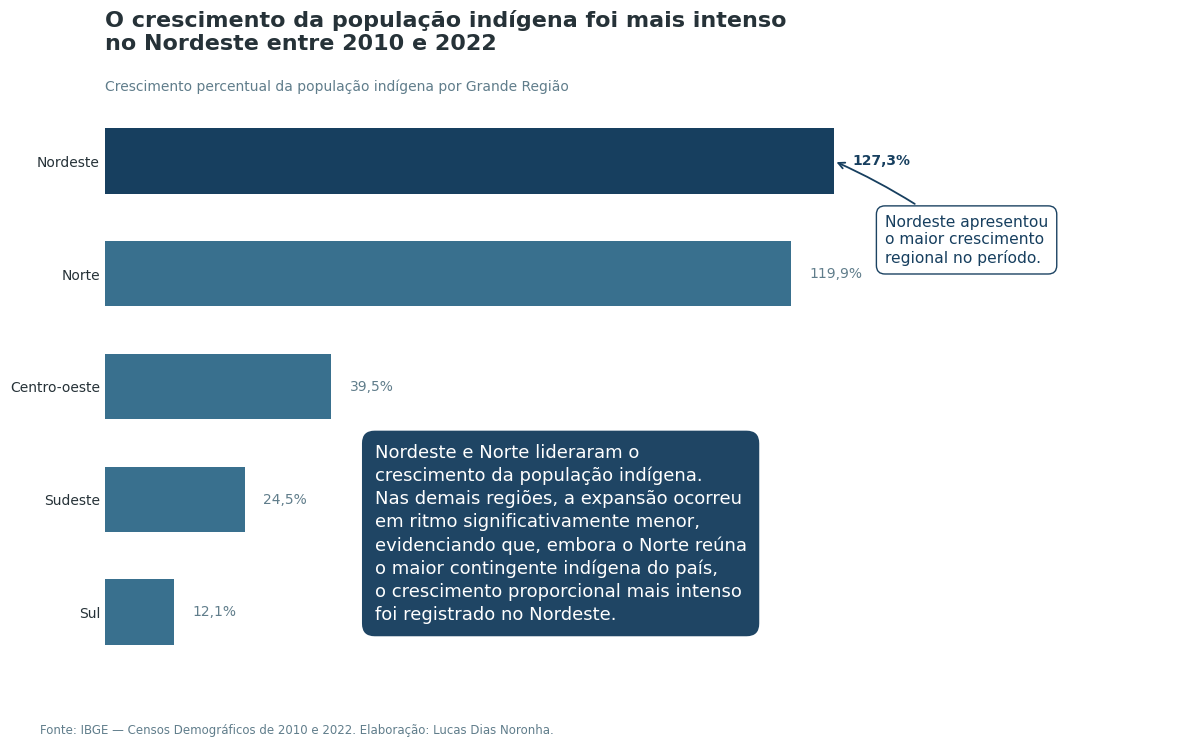

In [12]:
graficos_regionais.plot_crescimento_regional()

# Resposta
Entre 2010 e 2022, o Nordeste foi a Grande Região que apresentou o maior crescimento proporcional da população indígena, superando inclusive a Região Norte. Esse resultado evidencia que a expansão da população indígena ocorreu de forma mais acelerada no Nordeste, embora o Norte continue concentrando o maior contingente populacional indígena do Brasil.

# 2 Qual região possui a maior proporção de indígenas vivendo em áreas urbanas?

In [13]:
urbanizacao_regional = gdf_regioes.copy()

urbanizacao_regional["Percentual Urbano"] = (
    urbanizacao_regional["Indígenas 2022 Urbano"]
    / urbanizacao_regional["Indígenas 2022 Total"]
) * 100

urbanizacao_regional = (
    urbanizacao_regional[
        [
            "NM_REGIAO",
            "Percentual Urbano",
        ]
    ]
    .sort_values(
        "Percentual Urbano",
        ascending=False,
    )
)

urbanizacao_regional

,NM_REGIAO,Percentual Urbano
3,Sudeste,77.246140
1,Nordeste,62.298536
2,Norte,49.998010
4,Sul,41.799391
0,Centro-oeste,37.949968


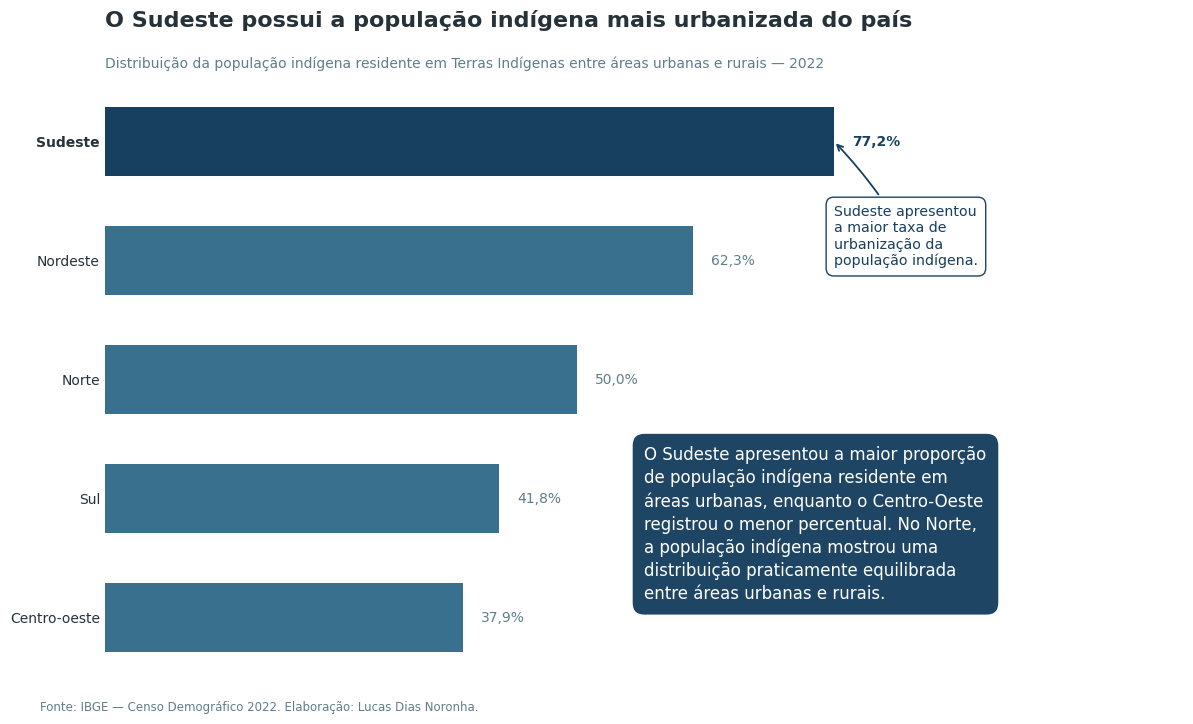

In [14]:
graficos_regionais.plot_urbanizacao_regional()

# Resposta

A Região Sudeste apresentou a maior proporção de população indígena residente em áreas urbanas, com 77,2%. Em contraste, o Centro-Oeste registrou o menor nível de urbanização (37,9%), enquanto o Norte apresentou uma distribuição praticamente equilibrada entre áreas urbanas e rurais, com 50,0% da população indígena vivendo em cidades.

# 3 A população indígena residente em Terras Indígenas é predominantemente urbana ou rural em cada Grande Região?

In [15]:
ti_urbano_rural = gdf_regioes.copy()

ti_urbano_rural["Percentual TI Urbano"] = (
    ti_urbano_rural["Indígenas 2022 TI Urbano"]
    / ti_urbano_rural["Indígenas 2022 TI Total"]
) * 100

ti_urbano_rural["Percentual TI Rural"] = (
    ti_urbano_rural["Indígenas 2022 TI Rural"]
    / ti_urbano_rural["Indígenas 2022 TI Total"]
) * 100

ti_urbano_rural = (
    ti_urbano_rural[
        [
            "NM_REGIAO",
            "Percentual TI Urbano",
            "Percentual TI Rural",
        ]
    ]
    .sort_values(
        "Percentual TI Urbano",
        ascending=False,
    )
    .reset_index(drop=True)
)

ti_urbano_rural

,NM_REGIAO,Percentual TI Urbano,Percentual TI Rural
0,Nordeste,23.251875,76.748125
1,Norte,11.038832,88.961168
2,Sudeste,8.083624,91.916376
3,Sul,3.219580,96.780420
4,Centro-oeste,1.550775,98.449225


In [16]:
ti_urbano_rural["Soma (%)"] = (
    ti_urbano_rural["Percentual TI Urbano"]
    + ti_urbano_rural["Percentual TI Rural"]
)

ti_urbano_rural[
    [
        "NM_REGIAO",
        "Soma (%)",
    ]
]

,NM_REGIAO,Soma (%)
0,Nordeste,100.0
1,Norte,100.0
2,Sudeste,100.0
3,Sul,100.0
4,Centro-oeste,100.0


In [17]:
dados = ti_urbano_rural.copy()

dados = (
    dados.sort_values(
        "Percentual TI Urbano",
        ascending=False,
    )
    .reset_index(drop=True)
)

dados

,NM_REGIAO,Percentual TI Urbano,Percentual TI Rural,Soma (%)
0,Nordeste,23.251875,76.748125,100.0
1,Norte,11.038832,88.961168,100.0
2,Sudeste,8.083624,91.916376,100.0
3,Sul,3.219580,96.780420,100.0
4,Centro-oeste,1.550775,98.449225,100.0


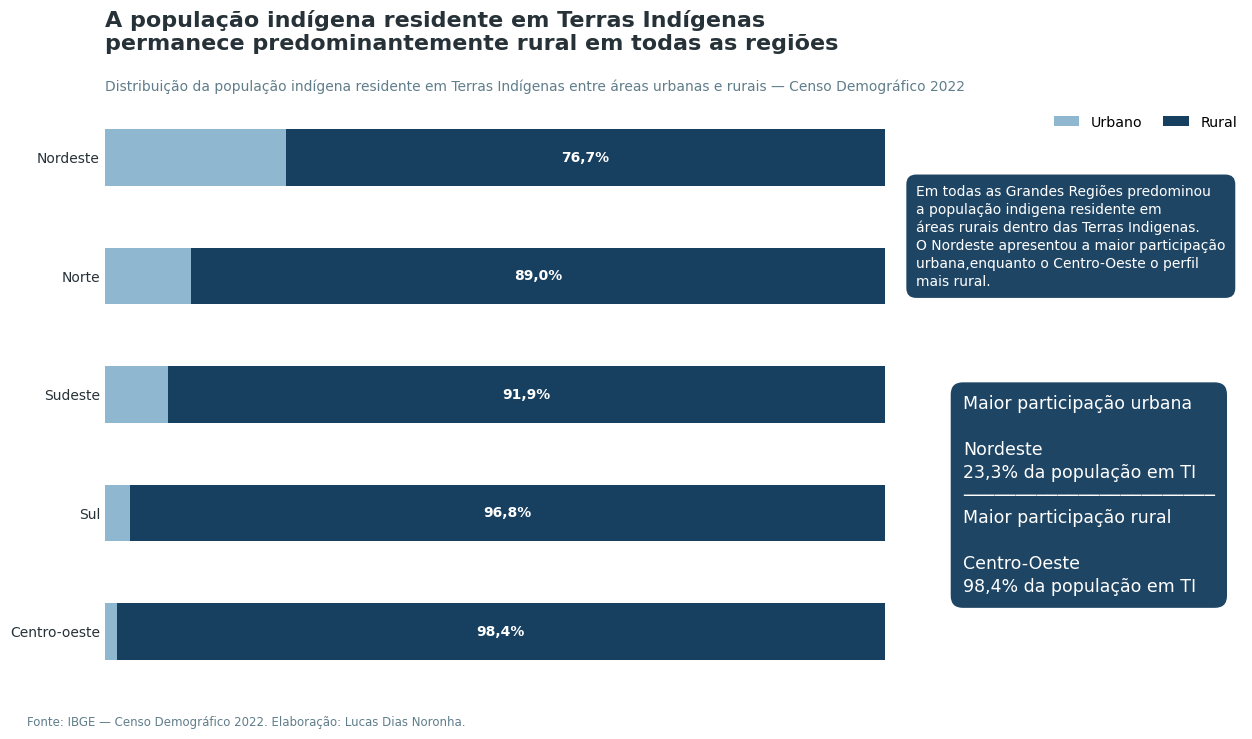

In [18]:
graficos_regionais.plot_urbanizacao_terras_indigenas()

# Resposta

A população indígena residente em Terras Indígenas apresentou um perfil predominantemente rural em todas as Grandes Regiões brasileiras. Mesmo na região com maior participação urbana, o Nordeste, cerca de três quartos dessa população ainda viviam em áreas rurais (76,7%). Nas demais regiões, essa predominância foi ainda mais acentuada, alcançando 98,4% no Centro-Oeste.

Esse padrão indica que, embora exista urbanização dentro das Terras Indígenas, ela permanece um fenômeno relativamente restrito. A ocupação continua fortemente associada ao meio rural, característica observada de forma consistente em todas as regiões do país.

# 4 Como a população indígena residente fora de Terras Indígenas se distribui entre áreas urbanas e rurais nas Grandes Regiões?

In [19]:
fora_ti_urbano_rural = gdf_regioes[
    [
        "NM_REGIAO",
        "Indígenas 2022 Fora TI Urbano",
        "Indígenas 2022 Fora TI Rural",
        "Indígenas 2022 Fora TI Total",
    ]
].copy()

fora_ti_urbano_rural["Percentual Fora TI Urbano"] = (
    fora_ti_urbano_rural["Indígenas 2022 Fora TI Urbano"]
    / fora_ti_urbano_rural["Indígenas 2022 Fora TI Total"]
) * 100

fora_ti_urbano_rural["Percentual Fora TI Rural"] = (
    fora_ti_urbano_rural["Indígenas 2022 Fora TI Rural"]
    / fora_ti_urbano_rural["Indígenas 2022 Fora TI Total"]
) * 100

fora_ti_urbano_rural = (
    fora_ti_urbano_rural
    .sort_values(
        "Percentual Fora TI Urbano",
        ascending=False,
    )
    .reset_index(drop=True)
)

fora_ti_urbano_rural

,NM_REGIAO,Indígenas 2022 Fora TI Urbano,Indígenas 2022 Fora TI Rural,Indígenas 2022 Fora TI Total,Percentual Fora TI Urbano,Percentual Fora TI Rural
0,Sudeste,93608,8301,101909,91.854498,8.145502
1,Centro-oeste,74187,11765,85952,86.312128,13.687872
2,Norte,341901,95052,436953,78.246631,21.753369
3,Nordeste,299439,99807,399246,75.001127,24.998873
4,Sul,35625,12307,47932,74.324042,25.675958


In [20]:
fora_ti_urbano_rural["Soma (%)"] = (
    fora_ti_urbano_rural["Percentual Fora TI Urbano"]
    + fora_ti_urbano_rural["Percentual Fora TI Rural"]
)

fora_ti_urbano_rural[
    [
        "NM_REGIAO",
        "Soma (%)",
    ]
]

,NM_REGIAO,Soma (%)
0,Sudeste,100.0
1,Centro-oeste,100.0
2,Norte,100.0
3,Nordeste,100.0
4,Sul,100.0


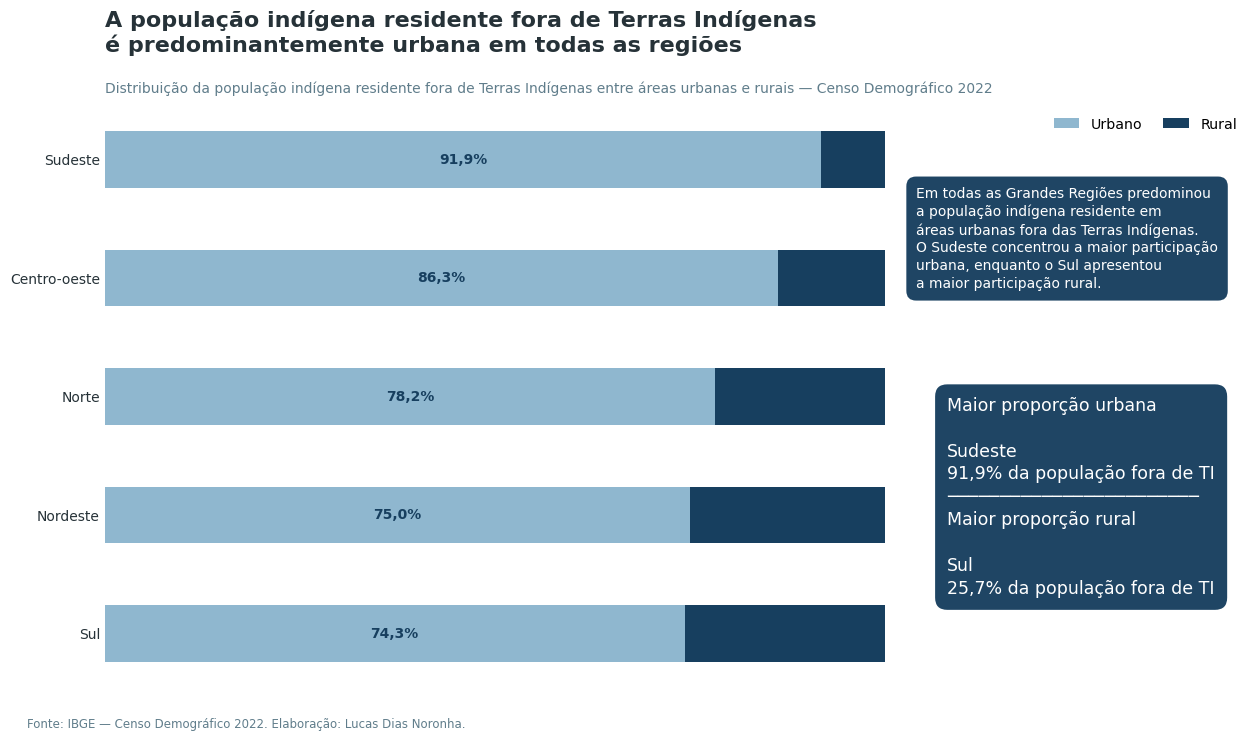

In [21]:
graficos_regionais.plot_urbanizacao_fora_terras_indigenas()

# Resposta

Fora das Terras Indígenas, a população indígena apresentou predominância urbana em todas as Grandes Regiões brasileiras. O Sudeste registrou a maior proporção de indígenas residentes em áreas urbanas (91,9%), enquanto o Sul apresentou a maior participação de residentes em áreas rurais (25,7%). Apesar das diferenças regionais, a urbanização predominou de forma consistente em todo o país, indicando que a população indígena que vive fora das Terras Indígenas está majoritariamente inserida em contextos urbanos.

# Como o perfil de residência da população indígena varia entre Terras Indígenas e fora delas nas Grandes Regiões?

In [24]:
import importlib
import src.visualization.plot_sintese_regional as psr

importlib.reload(psr)

PainelSinteseRegional = psr.PainelSinteseRegional

In [25]:
from pathlib import Path
from src.visualization.plot_sintese_regional import PainelSinteseRegional

painel = PainelSinteseRegional(
    gdf=gdf_regioes,
    diretorio_saida=Path("../report/figures"),
)

painel.plot()

In [23]:
gdf_regioes["NM_REGIAO"]

0    Centro-oeste
1        Nordeste
2           Norte
3         Sudeste
4             Sul
Name: NM_REGIAO, dtype: object

# Conclusão